<h1 style="text-align:center;  border-bottom: 2px solid #1E90FF;">
  Petrophysical Data Analysis - Part 2
</h1>


1. Advanced LAS File Handling and Exploration
2. Well Log Data Integration
3. Log Quality Control and Correction
4. Petrophysical Calculations
5. Multi-variate Log Visualization Techniques
6. Data Export and Integration with Geological Software


<hr style="border: 0; height: 2px; background-color: #1E90FF;">

In [29]:
import warnings
warnings.filterwarnings('ignore')

<h2 style="text-align:left; color:#1E90FF;">
  1. Advanced LAS File Handling and Exploration
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  1.1 Batch Processing of Multiple LAS Files
</h3>
Batch processing is crucial when dealing with multiple wells in a field or basin-wide study.

In [2]:
import os
import lasio
import pandas as pd

def process_las_files(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".las"):
            las = lasio.read(os.path.join(directory, filename))
            df = las.df()
            df['WELL'] = las.well.WELL.value
            dataframes.append(df)
    return pd.concat(dataframes, keys=[df['WELL'].iloc[0] for df in dataframes])

multi_well_data = process_las_files(r"C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets")

multi_well_data 

RHOB        DT       GR          AI     AI_REL    PHIE  \
      DEPTH                                                                    
F02-1 48.0000          NaN  524.0485      NaN  3820257.00  -455.6956     NaN   
      48.1500          NaN  524.0410      NaN  3820311.75  -455.6956     NaN   
      48.3000          NaN  524.0336      NaN  3820366.25  -455.6956     NaN   
      48.4500          NaN  524.0262      NaN  3820419.75  -455.6956     NaN   
      48.6000          NaN  524.0190      NaN  3820472.25  -455.6956     NaN   
...                    ...       ...      ...         ...        ...     ...   
F03-2 1502.8501  2079.5254  507.5121  57.4739  4097525.75 -9952.8086  0.3565   
      1503.0000  2082.3804  505.9146  54.3907  4116157.75 -9952.8086  0.3548   
      1503.1500  2076.4177  509.2799  47.7548  4077238.25 -9952.8086  0.3585   
      1503.3000  2081.9536  506.1183  46.7720  4113673.75 -9952.8086  0.3550   
      1503.4501  2073.4670  510.9702  50.1916  4057912.25 -9952.8086  0.3603   

                  WELL  
      DEPTH             
F02-1 48.0000    F02-1  
      48.1500    F02-1  
      48.3000    F02-1  
      48.4500    F02-1  
      48.6000    F02-1  
...                ...  
F03-2 1502.8501  F03-2  
      1503.0000  F03-2  
      1503.1500  F03-2  
      1503.3000  F03-2  
      1503.4501  F03-2  

[19504 rows x 7 columns]

<h3 style="text-align:left; color:#66CDAA;">
  1.2 Handling LAS File Versions and Inconsistencies
</h3>
Handling different LAS file versions and mnemonic inconsistencies is essential for robust data integration across multiple wells or datasets.

In [4]:
import lasio

def handle_las_versions(las_file):
    las = lasio.read(las_file)
    if las.version.VERS.value < 2.0:
        print(f"Warning: {las_file} is using an older LAS version.")
    
    # Check for inconsistent mnemonics
    standard_mnemonics = {'GR': 'GAMMA RAY', 'RHOB': 'BULK DENSITY', 'NPHI': 'NEUTRON POROSITY'}
    for curve in las.curves:
        if curve.mnemonic in standard_mnemonics and curve.descr != standard_mnemonics[curve.mnemonic]:
            print(f"Inconsistent description for {curve.mnemonic} in {las_file}")

handle_las_versions(r"C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets\F02-1_logs.las")

Inconsistent description for RHOB in C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets\F02-1_logs.las
Inconsistent description for GR in C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets\F02-1_logs.las


<h2 style="text-align:left; color:#1E90FF;">
  2. Well Log Data Integration
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  2.1 Depth Matching and Reconciliation
</h3>
Depth matching is crucial when combining logs with different sampling intervals or when aligning core data with log data.

In [ ]:
import numpy as np
from scipy.interpolate import interp1d



def depth_match(log1, depth1, log2, depth2):
    # Ensure depths are in ascending order
    sort_idx1 = np.argsort(depth1)
    sort_idx2 = np.argsort(depth2)
    
    depth1, log1 = depth1[sort_idx1], log1[sort_idx1]
    depth2, log2 = depth2[sort_idx2], log2[sort_idx2]
    
    # Create interpolation function
    f = interp1d(depth2, log2, kind='linear', fill_value='extrapolate')
    
    # Interpolate log2 to depth1
    log2_matched = f(depth1)
    
    return log1, log2_matched, depth1

gr_matched, density_matched, common_depth = depth_match(df['GR'], df.index, df['RHOB'], df.index)

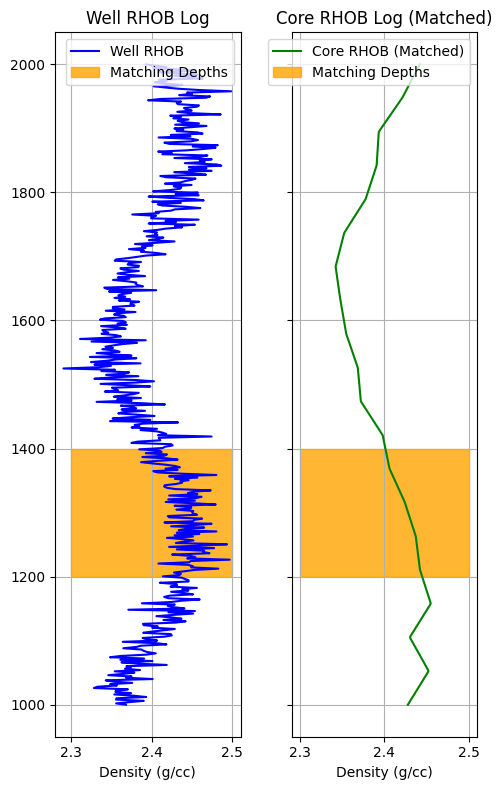

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d



# Define depth matching function
def depth_match(log1, depth1, log2, depth2):
    # Ensure depths are in ascending order
    sort_idx1 = np.argsort(depth1)
    sort_idx2 = np.argsort(depth2)
    
    depth1, log1 = depth1[sort_idx1], log1[sort_idx1]
    depth2, log2 = depth2[sort_idx2], log2[sort_idx2]
    
    # Interpolate core log to match well log depths
    f = interp1d(depth2, log2, kind='linear', fill_value='extrapolate')
    log2_matched = f(depth1)
    
    return log1, log2_matched, depth1

# Apply depth matching
well_rhob_matched, core_rhob_matched, common_depth = depth_match(well_rhob_log, depth1, core_rhob_log, depth2)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)

# Shaded region for depth matching example (e.g., between 1200 and 1400 m)
matching_start, matching_end = 1200, 1400

# Plot well log
ax[0].plot(well_rhob_log, depth1, color='blue', label='Well RHOB')
ax[0].fill_betweenx(depth1, 2.3, 2.5, where=(depth1 >= matching_start) & (depth1 <= matching_end), 
                    color='orange', alpha=0.8, label='Matching Depths')
ax[0].invert_yaxis()
ax[0].set_xlabel('Density (g/cc)')
ax[0].set_title('Well RHOB Log')
ax[0].grid(True)
ax[0].legend()

# Plot core log after depth matching
ax[1].plot(core_rhob_matched, common_depth, color='green', label='Core RHOB (Matched)')
ax[1].fill_betweenx(common_depth, 2.3, 2.5, where=(common_depth >= matching_start) & (common_depth <= matching_end), 
                    color='orange', alpha=0.8, label='Matching Depths')
ax[1].invert_yaxis()
ax[1].set_xlabel('Density (g/cc)')
ax[1].set_title('Core RHOB Log (Matched)')
ax[1].grid(True)
ax[1].legend()

# Overall layout adjustments
plt.tight_layout()
plt.show()


<h3 style="text-align:left; color:#66CDAA;">
  2.2 Integration of Directional Survey Data
</h3>
Integrating directional survey data allows for accurate spatial positioning of log data in deviated or horizontal wells, which is crucial for geological modeling and well correlation.

In [9]:
import pandas as pd
import numpy as np


well = pd.read_csv(r'C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets\xeek_data.csv')
well.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,34.636410,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000,1.0
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,34.636410,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000,1.0
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,34.779556,NaN,NaN,-0.574245,NaN,NaN,NaN,NaN,65000,1.0
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,39.965164,NaN,NaN,-0.586315,NaN,NaN,NaN,NaN,65000,1.0
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,57.483765,NaN,NaN,-0.597914,NaN,NaN,NaN,NaN,65000,1.0


In [11]:
well_1 = well[well['WELL'] == '15/9-13' ]

In [12]:
well_1.describe()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
count,18270.000000,18270.000000,1.827000e+04,18270.000000,18270.000000,1623.000000,18270.000000,18270.000000,18270.000000,18270.000000,...,18161.000000,0.0,0.0,18270.000000,17464.000000,0.0,0.0,1627.000000,18270.000000,18270.000000
mean,1883.228478,437627.322429,6.470979e+06,-1857.985240,14.789688,2.901504,1.835372,1.832040,2.110451,63.847477,...,27.115614,NaN,NaN,0.012675,0.139777,NaN,NaN,5.748493,60476.696223,1.039080
std,801.941195,14.359784,3.508944e+00,801.742890,4.377047,3.474120,2.891524,2.197939,0.297725,28.636331,...,30.452190,NaN,NaN,0.047393,0.009454,NaN,NaN,71.588789,13972.748152,0.276835
min,494.528000,437593.343750,6.470972e+06,-3246.156250,8.186605,0.175400,0.374989,0.352202,1.404576,6.191506,...,0.138586,NaN,NaN,-0.679026,0.129413,NaN,NaN,0.171424,30000.000000,1.000000
25%,1188.750000,437614.812500,6.470976e+06,-2552.392883,12.125232,0.934778,0.782044,0.799976,1.963399,43.866690,...,4.727499,NaN,NaN,-0.007219,0.133007,NaN,NaN,0.934500,65000.000000,1.000000
50%,1882.972000,437631.187500,6.470978e+06,-1857.799133,13.913155,1.473143,1.211789,1.293638,2.055079,66.777851,...,30.297560,NaN,NaN,0.001565,0.136602,NaN,NaN,1.455721,65000.000000,1.000000
75%,2577.802000,437640.781250,6.470982e+06,-1163.699371,18.309367,3.352066,2.067438,2.085021,2.381963,81.542681,...,39.995598,NaN,NaN,0.020022,0.144990,NaN,NaN,3.464941,65000.000000,1.000000
max,3272.024000,437642.812500,6.470984e+06,-469.501831,23.329569,54.536583,142.606338,49.221905,2.927888,499.022583,...,1083.425415,NaN,NaN,0.210927,0.156973,NaN,NaN,2000.000000,99000.000000,3.000000


In [21]:
df_survey = pd.read_csv(r'C:\Users\hp\Coding World\PE-Petrophysical Analytics\Datasets\15_9-13_directional_well.csv')

df_survey.head()

,MD,INC,AZI
0,494.528000,0.496714,150.267961
1,522.583515,0.770827,79.958812
2,550.639030,2.465870,43.151532
3,578.694545,4.250303,121.541462
4,606.750061,3.402210,339.447493


In [20]:
def calculate_tvd(md, inc, azi):
    """Calculate True Vertical Depth (TVD) from Measured Depth (MD), Inclination, and Azimuth"""
    dls = np.radians(np.sqrt(np.diff(inc)**2 + (np.diff(azi) * np.sin(np.radians(inc[:-1])))**2))
    tvd = [0]
    for i in range(1, len(md)):
        if dls[i-1] == 0:
            tvd.append(tvd[-1] + (md[i] - md[i-1]) * np.cos(np.radians(inc[i])))
        else:
            tvd.append(tvd[-1] + (md[i] - md[i-1]) * (2 / dls[i-1]) * np.sin(dls[i-1]/2) * 
                       (np.cos(np.radians(inc[i-1])) + np.cos(np.radians(inc[i]))))
    return np.array(tvd)

# Assuming df_survey contains the directional survey data
df_survey['TVD'] = calculate_tvd(df_survey['MD'], df_survey['INC'], df_survey['AZI'])

# Interpolate TVD to log depths
f_tvd = interp1d(df_survey['MD'], df_survey['TVD'], kind='cubic', fill_value='extrapolate')
well_1['TVD'] = f_tvd(well_1.index)

C:\Users\hp\AppData\Local\Temp\ipykernel_23156\1873679093.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_1['TVD'] = f_tvd(well_1.index)


In [18]:
well_1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,TVD
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000,1.0,-986.734170
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000,1.0,-984.755209
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,NaN,NaN,-0.574245,NaN,NaN,NaN,NaN,65000,1.0,-982.776136
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,NaN,NaN,-0.586315,NaN,NaN,NaN,NaN,65000,1.0,-980.796951
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,NaN,NaN,-0.597914,NaN,NaN,NaN,NaN,65000,1.0,-978.817654


C:\Users\hp\AppData\Local\Temp\ipykernel_23156\1480695820.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_1['TVD'] = f_tvd(well_1.index)


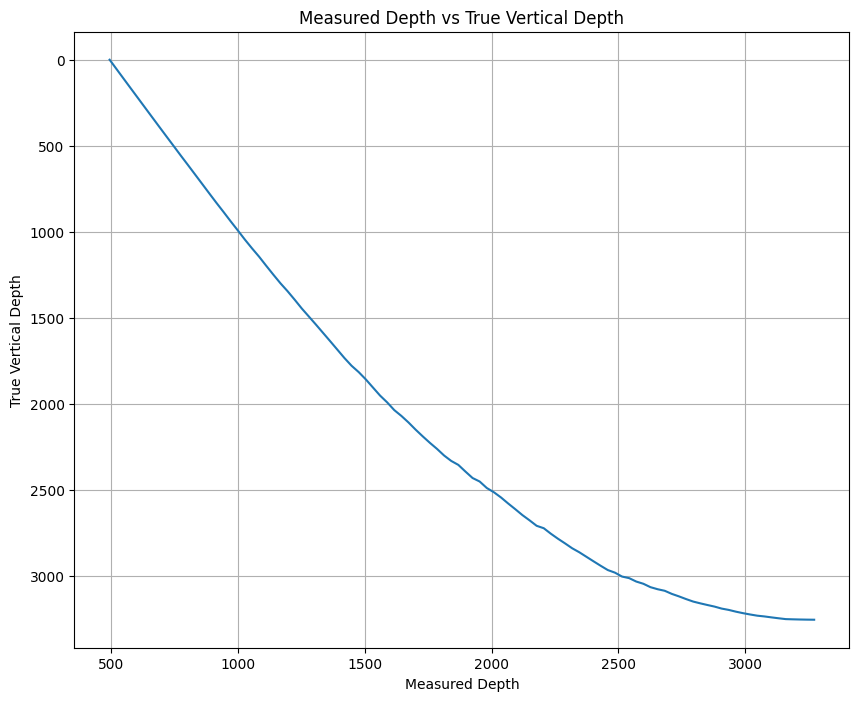

TVD calculation completed successfully.
TVD range: -988.99 to 3521.38


In [24]:
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import matplotlib.pyplot as plt

def calculate_tvd(md, inc, azi):
    """Calculate True Vertical Depth (TVD) from Measured Depth (MD), Inclination, and Azimuth"""
    
    rad_inc = np.radians(inc)
    rad_azi = np.radians(azi)
    
    dls = np.radians(np.sqrt(np.diff(inc)**2 + (np.diff(azi) * np.sin(rad_inc[:-1]))**2))
    tvd = [0]
    
    for i in range(1, len(md)):
        delta_md = md[i] - md[i-1]
        if dls[i-1] < 1e-6:
            delta_tvd = delta_md * np.cos(rad_inc[i])
        else:
            delta_tvd = delta_md * (2 / dls[i-1]) * np.sin(dls[i-1]/2) * \
                        (np.cos(rad_inc[i-1]) + np.cos(rad_inc[i]))
        
        new_tvd = tvd[-1] + delta_tvd
        tvd.append(max(new_tvd, tvd[-1]))  # Ensure TVD never decreases
    
    return np.array(tvd)

def plot_md_vs_tvd(md, tvd):
    """Plot MD vs TVD for visualization"""
    plt.figure(figsize=(10, 8))
    plt.plot(md, tvd)
    plt.title('Measured Depth vs True Vertical Depth')
    plt.xlabel('Measured Depth')
    plt.ylabel('True Vertical Depth')
    plt.gca().invert_yaxis()  # Invert y-axis to show increasing depth downwards
    plt.grid(True)
    plt.show()

    
df_survey['TVD'] = calculate_tvd(df_survey['MD'].values, df_survey['INC'].values, df_survey['AZI'].values)

# Interpolate TVD to log depths
f_tvd = interp1d(df_survey['MD'], df_survey['TVD'], kind='linear', fill_value='extrapolate')

well_1['TVD'] = f_tvd(well_1.index)

# Plot MD vs TVD for visualization
plot_md_vs_tvd(df_survey['MD'], df_survey['TVD'])

print("TVD calculation completed successfully.")
print(f"TVD range: {well_1['TVD'].min():.2f} to {well_1['TVD'].max():.2f}")

<h2 style="text-align:left; color:#1E90FF;">
  3. Log Quality Control and Correction
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  3.1 Environmental Corrections
</h3>
Environmental corrections are essential for accurate petrophysical analysis, accounting for borehole and formation effects on log measurements.

In [ ]:
def density_correction(rhob, gcr):
    """Basic density correction for shale effect"""
    return rhob + 0.01378 * (gcr - 60)  # Simplified correction

df['RHOB_CORR'] = density_correction(df['RHOB'], df['GR'])

def neutron_gas_correction(nphi, rho):
    """Basic neutron porosity correction for gas effect"""
    return nphi * (0.995 + 0.0075 * ((rho - 2.65) / (1 - 2.65)))

df['NPHI_CORR'] = neutron_gas_correction(df['NPHI'], df['RHOB'])

<h3 style="text-align:left; color:#66CDAA;">
  3.2 Borehole Correction
</h3>
Borehole corrections account for the impact of borehole size and shape on log measurements, particularly important in washed-out zones.

In [32]:
def caliper_correction(log_value, caliper, bit_size, correction_factor=0.1):
    """Basic borehole size correction"""
    return log_value * (1 + correction_factor * (caliper - bit_size) / bit_size)

well_1['GR_CORR'] = caliper_correction(well_1['GR'], well_1['CALI'], bit_size=8.5, correction_factor=0.15)

well_1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,TVD,PHID,PHIE,VSH_LINEAR,VSH_CLAVIER,GR_CORR
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,NaN,NaN,65000,1.0,-988.987057,0.464130,NaN,0.756582,0.578229,95.742128
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,NaN,NaN,65000,1.0,-986.987196,0.460731,NaN,0.745754,0.564308,94.605569
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,NaN,NaN,65000,1.0,-984.987336,0.456653,NaN,0.694489,0.501917,89.305072
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,NaN,NaN,65000,1.0,-982.987475,0.459447,NaN,0.672058,0.476294,86.973639
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,NaN,NaN,65000,1.0,-980.987614,0.466646,NaN,0.658785,0.461572,85.593667


<h2 style="text-align:left; color:#1E90FF;">
  4. Petrophysical Calculations
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  4.1 Shale Volume Calculation
</h3>
Shale volume is a fundamental petrophysical property used in many subsequent calculations, including porosity and water saturation.

In [31]:
def calculate_vsh_linear(gr, gr_clean, gr_shale):
    return (gr - gr_clean) / (gr_shale - gr_clean)

def calculate_vsh_clavier(vsh_linear):
    return 1.7 - np.sqrt(3.38 - (vsh_linear + 0.7)**2)

gr_clean, gr_shale = well_1['GR'].quantile(0.05), well_1['GR'].quantile(0.95)
well_1['VSH_LINEAR'] = calculate_vsh_linear(well_1['GR'], gr_clean, gr_shale)
well_1['VSH_CLAVIER'] = calculate_vsh_clavier(well_1['VSH_LINEAR'])

well_1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,TVD,PHID,PHIE,VSH_LINEAR,VSH_CLAVIER
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,NaN,NaN,NaN,65000,1.0,-988.987057,0.464130,NaN,0.756582,0.578229
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,NaN,NaN,NaN,65000,1.0,-986.987196,0.460731,NaN,0.745754,0.564308
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,NaN,NaN,NaN,65000,1.0,-984.987336,0.456653,NaN,0.694489,0.501917
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,NaN,NaN,NaN,65000,1.0,-982.987475,0.459447,NaN,0.672058,0.476294
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,NaN,NaN,NaN,65000,1.0,-980.987614,0.466646,NaN,0.658785,0.461572


<h3 style="text-align:left; color:#66CDAA;">
  4.2 Porosity Calculation
</h3>
Accurate porosity calculation is crucial for reservoir characterization and volumetric estimates.

In [30]:
def calculate_density_porosity(rho_b, rho_ma, rho_f):
    return (rho_ma - rho_b) / (rho_ma - rho_f)

def calculate_neutron_density_porosity(nphi, phid):
    return np.sqrt((nphi**2 + phid**2) / 2)

well_1['PHID'] = calculate_density_porosity(well_1['RHOB'], rho_ma=2.65, rho_f=1.0)
well_1['PHIE'] = calculate_neutron_density_porosity(well_1['NPHI'], well_1['PHID'])

well_1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,TVD,PHID,PHIE
0,15/9-13,494.528,437641.96875,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,-0.574928,NaN,NaN,NaN,NaN,65000,1.0,-988.987057,0.464130,NaN
1,15/9-13,494.680,437641.96875,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,-0.570188,NaN,NaN,NaN,NaN,65000,1.0,-986.987196,0.460731,NaN
2,15/9-13,494.832,437641.96875,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,-0.574245,NaN,NaN,NaN,NaN,65000,1.0,-984.987336,0.456653,NaN
3,15/9-13,494.984,437641.96875,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,-0.586315,NaN,NaN,NaN,NaN,65000,1.0,-982.987475,0.459447,NaN
4,15/9-13,495.136,437641.96875,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,-0.597914,NaN,NaN,NaN,NaN,65000,1.0,-980.987614,0.466646,NaN


<h2 style="text-align:left; color:#1E90FF;">
  5. Multi-variate Log Visualization Techniques
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  5.1 Crossplot Analysis
</h3>
Crossplot analysis is a powerful technique for lithology identification and fluid content estimation.

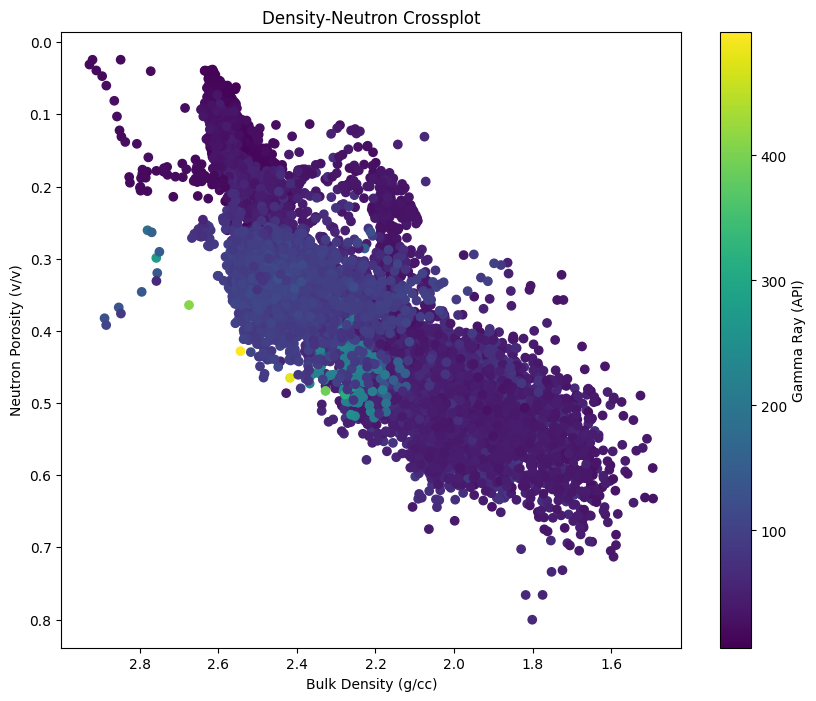

In [26]:
import matplotlib.pyplot as plt

def density_neutron_crossplot(rhob, nphi, gr, depth):
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(rhob, nphi, c=gr, cmap='viridis')
    ax.set_xlabel('Bulk Density (g/cc)')
    ax.set_ylabel('Neutron Porosity (v/v)')
    ax.invert_xaxis()
    ax.invert_yaxis()
    plt.colorbar(scatter, label='Gamma Ray (API)')
    plt.title('Density-Neutron Crossplot')
    plt.show()

density_neutron_crossplot(well_1['RHOB'], well_1['NPHI'], well_1['GR'], well_1.index)

<h3 style="text-align:left; color:#66CDAA;">
  5.2 Multi-Panel Log Plotting
</h3>
Advanced log plotting techniques allow for comprehensive visualization of multiple log curves and calculated properties, facilitating integrated interpretation.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def advanced_log_plot(df):
    fig, ax = plt.subplots(figsize=(15, 10))
    divider = make_axes_locatable(ax)
    
    # GR Log
    ax_gr = divider.append_axes("left", size="20%", pad="0%")
    ax_gr.plot(df['GR'], df.index, color='green')
    ax_gr.set_xlabel('GR (API)')
    ax_gr.set_ylim(ax_gr.get_ylim()[::-1])
    ax_gr.grid(True)
    
    # Resistivity Log
    ax_res = divider.append_axes("left", size="20%", pad="0%")
    ax_res.semilogx(df['RT'], df.index, color='red')
    ax_res.set_xlabel('RT (ohm.m)')
    ax_res.set_ylim(ax_res.get_ylim()[::-1])
    ax_res.grid(True)
    
    # Density-Neutron Log
    ax_dn = divider.append_axes("left", size="20%", pad="0%")
    ax_dn.plot(df['RHOB'], df.index, color='red', label='RHOB')
    ax_dn.plot(df['NPHI'], df.index, color='blue', label='NPHI')
    ax_dn.set_xlabel('RHOB (g/cc) / NPHI (v/v)')
    ax_dn.set_ylim(ax_dn.get_ylim()[::-1])
    ax_dn.grid(True)
    ax_dn.legend()
    
    # Calculated Properties
    ax_calc = divider.append_axes("left", size="20%", pad="0%")
    ax_calc.plot(df['VSH_CLAVIER'], df.index, color='brown', label='Vsh')
    ax_calc.plot(df['PHIE'], df.index, color='green', label='PHIE')
    ax_calc.set_xlabel('Vsh / PHIE (v/v)')
    ax_calc.set_ylim(ax_calc.get_ylim()[::-1])
    ax_calc.grid(True)
    ax_calc.legend()
    
    plt.tight_layout()
    plt.show()

advanced_log_plot(df)


<h2 style="text-align:left; color:#1E90FF;">
  6. Data Export and Integration with Geological Software
</h2>

<h3 style="text-align:left; color:#66CDAA;">
  6.1 Exporting to LAS Format
</h3>
Exporting processed data back to LAS format ensures compatibility with industry-standard geological and petrophysical software.

In [ ]:
import lasio

def export_to_las(df, well_info, output_file):
    las = lasio.LASFile()
    
    # Add well information
    for key, value in well_info.items():
        las.well[key] = value
    
    # Add curve data
    for column in df.columns:
        las.append_curve(column, df[column].values, unit='', descr='')
    
    # Write to file
    las.write(output_file, version=2.0)

well_info = {
    'WELL': 'Example Well',
    'UWI': '12345678',
    'API': '12-345-67890',
    'LOCATION': 'Block A',
    'SRVC': 'Logging Company'
}

export_to_las(df, well_info, 'processed_log.las')